<a href="https://colab.research.google.com/github/Sreejani17/Sreejani17/blob/main/house_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 House Price Prediction — Supervised Learning (Regression)

A beginner machine learning project that predicts California housing prices
using Linear Regression, built with scikit-learn.

**Goal:** Predict `median_house_value` based on features like income,
location, and house age.

**Tech stack:** Python, pandas, scikit-learn, matplotlib

**Author:** [Sreejani Parampogu] | [https://github.com/Sreejani17]

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
import pandas as pd

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
df = df.dropna()

In [15]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [16]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

## 1. Load the Dataset
We use the California Housing dataset, which contains housing block data
from the 1990 California census.

In [17]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 2. Explore the Data
Quick statistical summary to understand the ranges and spot anomalies.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(16346, 12) (4087, 12)


## 3. Prepare Features and Target
We separate our input features (X) from what we want to predict (y — the price),
then split the data so we can fairly test the model on unseen examples later.

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test)

## 4. Train the Model
We use Linear Regression to learn the relationship between housing features
and price.

In [22]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: 50413.433
Root Mean Squared Error: 69297.717
R² Score: 0.649


## 5. Evaluate Performance
We measure how far off our predictions are using MAE, RMSE, and R².

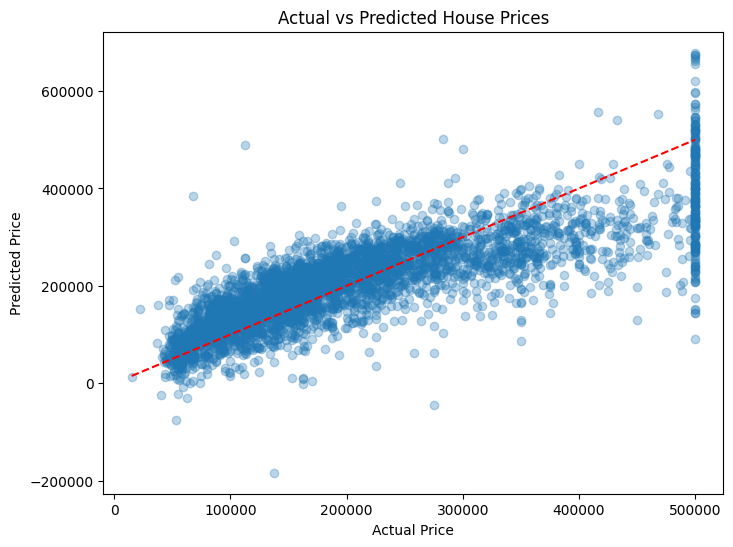

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## 6. Conclusion

- The Linear Regression model achieved an R² score of **[insert your score]**,
  meaning it explains about **[X]%** of the variation in housing prices.
- **Limitations:** Linear Regression assumes a straight-line relationship,
  which may not capture the more complex patterns in housing data.
- **Next steps:** Try ensemble models like Random Forest or Gradient Boosting
  to improve accuracy.